# Dataset Processing and Merging

This notebook processes multiple CSV files containing railway data, examines their structure, groups them by polling rates, and creates merged datasets.

## 1. Import Required Libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import os
import glob
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load CSV Files

We'll load all CSV files from the FEB 2025 Prototype data folder and store them in a dictionary.

In [2]:
# Set the data directory
data_dir = '/home/understressengineer/programming/SRM_PS1/FEB 2025 Prototype data'

# Get a list of all CSV files in the directory
csv_files = glob.glob(os.path.join(data_dir, '*.csv'))

# Create a dictionary to store the dataframes
dataframes = {}

# Load each CSV file with a progress bar
for file_path in tqdm(csv_files, desc="Loading CSV files"):
    # Extract filename without extension to use as dictionary key
    file_name = os.path.basename(file_path).split('.')[0]
    
    # Read the CSV file
    df = pd.read_csv(file_path)
    
    # Store the dataframe in the dictionary
    dataframes[file_name] = df
    
print(f"Loaded {len(dataframes)} CSV files successfully.")
print("Available datasets:", list(dataframes.keys()))

Loading CSV files:   0%|          | 0/12 [00:00<?, ?it/s]

/tmp/ipykernel_43124/1895970268.py:16: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Loaded 12 CSV files successfully.
Available datasets: ['WR', 'NR', 'NCR', 'CR', 'SCR', 'NFR', 'ECOR', 'ECR', 'WCR', 'SR', 'NER', 'SECR']


## 3. Examine Data Structure

Let's examine the structure of each CSV file to check column names, data types, and missing values.

In [3]:
# Create a function to get dataset summary information
def get_dataset_summary(df):
    return {
        'columns': list(df.columns),
        'shape': df.shape,
        'dtypes': df.dtypes.to_dict(),
        'missing_values': df.isna().sum().to_dict()
    }

# Create a summary for each dataset
dataset_summaries = {}
for name, df in dataframes.items():
    dataset_summaries[name] = get_dataset_summary(df)

# Create a summary table for all datasets
summary_table = pd.DataFrame({
    'Dataset': list(dataframes.keys()),
    'Rows': [df.shape[0] for df in dataframes.values()],
    'Columns': [df.shape[1] for df in dataframes.values()],
    'Column Names': [', '.join(df.columns) for df in dataframes.values()],
    'Missing Values': [df.isna().sum().sum() for df in dataframes.values()]
})

# Display the summary table
display(summary_table)

# Show detailed information for the first dataset as an example
first_dataset = list(dataframes.keys())[0]
print(f"\nDetailed information for {first_dataset}:")
display(dataframes[first_dataset].head())
display(dataframes[first_dataset].describe())

,Dataset,Rows,Columns,Column Names,Missing Values
0,WR,341322,12,"Time, Site Name, Point Machine Name, Direction...",104034
1,NR,52334,12,"Time, Site Name, Point Machine Name, Direction...",12919
2,NCR,49244,12,"Time, Site Name, Point Machine Name, Direction...",666
3,CR,105881,12,"Time, Site Name, Point Machine Name, Direction...",109177
4,SCR,714,12,"Time, Site Name, Point Machine Name, Direction...",296
5,NFR,93138,12,"Time, Site Name, Point Machine Name, Direction...",85740
6,ECOR,93553,12,"Time, Site Name, Point Machine Name, Direction...",45166
7,ECR,363007,12,"Time, Site Name, Point Machine Name, Direction...",74686
8,WCR,17876,12,"Time, Site Name, Point Machine Name, Direction...",164
9,SR,230590,12,"Time, Site Name, Point Machine Name, Direction...",54132



Detailed information for WR:


,Time,Site Name,Point Machine Name,Direction,A Current,A Voltage,B Current,B Voltage,Type of A,Type of B,Polling of A,Polling of B
0,2025-02-10 01:04:09,Atul,101/102,Reverse,"0.0,1.5,4.9,4.5,3.7,3,2.6,2.3,2.1,1.9,1.9,1.8,...","0.0,13.5,46.5,72.0,88.5,99.0,103.5,108.0,109.5...","0,5.8,5.2,4.1,3.3,2.8,2.4,2.1,2,1.8,1.8,1.7,1....","0.0,85.5,88.5,97.5,102.0,106.5,109.5,111.0,111...",TWS,IRS,100,100.0
1,2025-02-10 01:12:10,Atul,101/102,Normal,"0,5.2,4.9,4,3.3,2.8,2.4,2.2,2,1.9,1.8,1.8,1.8,...","0.0,88.5,90.0,97.5,102.0,105.0,108.0,109.5,111...","0.0,4.4,5.2,4.2,3.5,2.9,2.5,2.2,2,1.8,1.7,1.7,...","0.0,24.0,54.0,78.0,91.5,99.0,105.0,108.0,109.5...",TWS,IRS,100,100.0
2,2025-02-10 07:13:06,Atul,101/102,Reverse,"0.0,3.2,4.9,4.2,3.5,2.9,2.5,2.2,2,1.9,2,2,2,2....","0.0,25.5,55.5,78.0,91.5,100.5,105.0,108.0,109....","0,5.8,5.3,4.1,3.3,2.8,2.4,2.1,2,1.8,1.8,1.7,1....","0.0,84.0,88.5,97.5,103.5,106.5,109.5,111.0,112...",TWS,IRS,100,100.0
3,2025-02-10 08:00:53,Atul,101/102,Reverse,"0.0,4.5,4.7,3.9,3.2,2.7,2.4,2.1,2,1.9,1.9,1.9,...","0.0,37.5,66.0,84.0,96.0,102.0,106.5,109.5,111....","0,5.5,5.4,4.3,3.4,2.9,2.5,2.2,2,1.8,1.8,1.7,1....","0.0,87.0,87.0,96.0,102.0,106.5,108.0,111.0,111...",TWS,IRS,100,100.0
4,2025-02-10 08:03:36,Atul,101/102,Normal,"0,5.1,5.1,4.1,3.4,2.9,2.5,2.2,2,1.9,1.8,1.8,1....","0.0,90.0,90.0,96.0,102.0,105.0,108.0,109.5,111...","0.0,3.5,5.5,4.4,3.6,3,2.6,2.2,2,1.8,1.7,1.7,1....","0.0,18.0,48.0,75.0,90.0,97.5,103.5,108.0,109.5...",TWS,IRS,100,100.0


,Polling of A,Polling of B
count,341322.000000,290328.000000
mean,52.626552,52.471412
std,39.314588,39.285184
min,20.000000,20.000000
25%,20.000000,20.000000
50%,20.000000,20.000000
75%,100.000000,100.000000
max,100.000000,100.000000


## 4. Check Polling Rates

We need to identify the polling rate for each dataset (typically 20 or 100). We'll examine the timestamp differences to determine this.

In [7]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

def identify_polling_rate(df):
    """
    Identifies the polling rate for a given DataFrame.
    Priority:
      1. Use 'Polling of A' or 'Polling of B' columns if present.
      2. Infer from time column if polling columns are missing.
    """
    # 1. Check for polling columns directly
    polling_cols = [col for col in df.columns if 'polling' in col.lower()]
    for col in polling_cols:
        # Use the most common value if column exists and is numeric
        vals = pd.to_numeric(df[col], errors='coerce').dropna()
        if not vals.empty:
            # Round to nearest 10 to avoid minor floating errors
            mode = vals.mode()
            if not mode.empty:
                val = int(round(mode.iloc[0] / 10) * 10)
                if val in [20, 100]:
                    return val
                else:
                    return f"~{val}"

    # 2. If polling columns are missing, infer from time column
    # Try to find a time column
    possible_time_columns = ['time', 'timestamp', 'datetime', 'date_time', 't']
    time_column = None
    for col in df.columns:
        if any(name in col.lower() for name in possible_time_columns):
            time_column = col
            break
    if time_column is not None:
        # Try to convert to datetime
        try:
            time_series = pd.to_datetime(df[time_column], errors='coerce')
            # Drop NaT values
            time_series = time_series.dropna()
            # Convert to seconds
            time_values = time_series.astype(np.int64) // 10**9
            if len(time_values) < 2:
                return "Unknown (Insufficient time data)"
            time_diffs = np.diff(time_values)
            time_diffs = time_diffs[time_diffs > 0]
            if len(time_diffs) == 0:
                return "Unknown (No positive time diffs)"
            median_diff = np.median(time_diffs)
            polling_rate = 1.0 / median_diff if median_diff > 0 else 0
            # Round to nearest standard polling rate
            if 18 <= polling_rate <= 22:
                return 20
            elif 95 <= polling_rate <= 105:
                return 100
            else:
                return f"~{polling_rate:.1f}"
        except Exception as e:
            return f"Unknown (Error: {e})"
    return "Unknown (No polling or time column)"

# Apply to all loaded dataframes
polling_rates = {}
for name, df in tqdm(dataframes.items(), desc="Checking polling rates"):
    polling_rates[name] = identify_polling_rate(df)

# Group datasets by polling rate
datasets_by_rate = {}
for name, rate in polling_rates.items():
    datasets_by_rate.setdefault(rate, []).append(name)

# Display as DataFrame for clarity
polling_rate_df = pd.DataFrame({
    'Dataset': list(polling_rates.keys()),
    'Polling Rate (Hz)': list(polling_rates.values())
})
display(polling_rate_df)

print("\nDatasets grouped by polling rate:")
for rate, datasets in datasets_by_rate.items():
    print(f"Rate: {rate} Hz - {len(datasets)} datasets: {', '.join(datasets)}")


Checking polling rates:   0%|          | 0/12 [00:00<?, ?it/s]

,Dataset,Polling Rate (Hz)
0,WR,20
1,NR,20
2,NCR,100
3,CR,100
4,SCR,20
5,NFR,100
6,ECOR,100
7,ECR,100
8,WCR,100
9,SR,100



Datasets grouped by polling rate:
Rate: 20 Hz - 3 datasets: WR, NR, SCR
Rate: 100 Hz - 9 datasets: NCR, CR, NFR, ECOR, ECR, WCR, SR, NER, SECR


## 5. Merge Datasets by Polling Rate

We'll merge datasets with the same polling rate to create unified datasets.

In [8]:
# Function to merge datasets with the same polling rate
def merge_datasets_by_rate(rate, dataset_names):
    if not dataset_names:
        return None
    
    # Initialize merged dataframe with the first dataset
    first_dataset = dataset_names[0]
    merged_df = dataframes[first_dataset].copy()
    merged_df['source_dataset'] = first_dataset
    
    # Add all other datasets
    for dataset_name in tqdm(dataset_names[1:], desc=f"Merging datasets with rate {rate}Hz"):
        df = dataframes[dataset_name].copy()
        df['source_dataset'] = dataset_name
        merged_df = pd.concat([merged_df, df], ignore_index=True)
    
    return merged_df

# Create merged datasets for each polling rate
merged_datasets = {}
for rate, datasets in datasets_by_rate.items():
    print(f"\nMerging datasets with polling rate: {rate}Hz")
    merged_datasets[rate] = merge_datasets_by_rate(rate, datasets)
    
    if merged_datasets[rate] is not None:
        print(f"Created merged dataset with {merged_datasets[rate].shape[0]} rows and {merged_datasets[rate].shape[1]} columns")
        
# Show a sample of each merged dataset
for rate, df in merged_datasets.items():
    if df is not None:
        print(f"\nSample of merged dataset with polling rate {rate}Hz:")
        display(df.head())


Merging datasets with polling rate: 20Hz


Merging datasets with rate 20Hz:   0%|          | 0/2 [00:00<?, ?it/s]

Created merged dataset with 394370 rows and 13 columns

Merging datasets with polling rate: 100Hz


Merging datasets with rate 100Hz:   0%|          | 0/8 [00:00<?, ?it/s]

Created merged dataset with 1193466 rows and 13 columns

Sample of merged dataset with polling rate 20Hz:


,Time,Site Name,Point Machine Name,Direction,A Current,A Voltage,B Current,B Voltage,Type of A,Type of B,Polling of A,Polling of B,source_dataset
0,2025-02-10 01:04:09,Atul,101/102,Reverse,"0.0,1.5,4.9,4.5,3.7,3,2.6,2.3,2.1,1.9,1.9,1.8,...","0.0,13.5,46.5,72.0,88.5,99.0,103.5,108.0,109.5...","0,5.8,5.2,4.1,3.3,2.8,2.4,2.1,2,1.8,1.8,1.7,1....","0.0,85.5,88.5,97.5,102.0,106.5,109.5,111.0,111...",TWS,IRS,100,100.0,WR
1,2025-02-10 01:12:10,Atul,101/102,Normal,"0,5.2,4.9,4,3.3,2.8,2.4,2.2,2,1.9,1.8,1.8,1.8,...","0.0,88.5,90.0,97.5,102.0,105.0,108.0,109.5,111...","0.0,4.4,5.2,4.2,3.5,2.9,2.5,2.2,2,1.8,1.7,1.7,...","0.0,24.0,54.0,78.0,91.5,99.0,105.0,108.0,109.5...",TWS,IRS,100,100.0,WR
2,2025-02-10 07:13:06,Atul,101/102,Reverse,"0.0,3.2,4.9,4.2,3.5,2.9,2.5,2.2,2,1.9,2,2,2,2....","0.0,25.5,55.5,78.0,91.5,100.5,105.0,108.0,109....","0,5.8,5.3,4.1,3.3,2.8,2.4,2.1,2,1.8,1.8,1.7,1....","0.0,84.0,88.5,97.5,103.5,106.5,109.5,111.0,112...",TWS,IRS,100,100.0,WR
3,2025-02-10 08:00:53,Atul,101/102,Reverse,"0.0,4.5,4.7,3.9,3.2,2.7,2.4,2.1,2,1.9,1.9,1.9,...","0.0,37.5,66.0,84.0,96.0,102.0,106.5,109.5,111....","0,5.5,5.4,4.3,3.4,2.9,2.5,2.2,2,1.8,1.8,1.7,1....","0.0,87.0,87.0,96.0,102.0,106.5,108.0,111.0,111...",TWS,IRS,100,100.0,WR
4,2025-02-10 08:03:36,Atul,101/102,Normal,"0,5.1,5.1,4.1,3.4,2.9,2.5,2.2,2,1.9,1.8,1.8,1....","0.0,90.0,90.0,96.0,102.0,105.0,108.0,109.5,111...","0.0,3.5,5.5,4.4,3.6,3,2.6,2.2,2,1.8,1.7,1.7,1....","0.0,18.0,48.0,75.0,90.0,97.5,103.5,108.0,109.5...",TWS,IRS,100,100.0,WR



Sample of merged dataset with polling rate 100Hz:


,Time,Site Name,Point Machine Name,Direction,A Current,A Voltage,B Current,B Voltage,Type of A,Type of B,Polling of A,Polling of B,source_dataset
0,2025-02-10 00:08:57,Gwalior,PT107A/B,Reverse,"0,4.5,4.1,3.4,2.9,2.6,2.3,2,1.8,1.7,1.6,1.6,1....","0.0,115.5,117.0,118.5,121.5,121.5,123.0,124.5,...","0.0,5.8,5,3.9,3.2,2.7,2.3,2.1,1.9,1.8,1.7,1.6,...","0.0,45.0,84.0,103.5,114.0,118.5,121.5,123.0,12...",IRS,IRS,100,100.0,NCR
1,2025-02-10 00:13:00,Gwalior,PT107A/B,Normal,"0.0,3.8,3.8,3.2,2.7,2.3,2,1.8,1.7,1.6,1.6,1.5,...","0.0,51.0,88.5,106.5,115.5,120.0,123.0,124.5,12...","0,3,6.2,4.8,3.7,3.1,2.7,2.3,2.1,1.9,1.8,1.7,1....","0.0,124.5,109.5,114.0,118.5,121.5,123.0,124.5,...",IRS,IRS,100,100.0,NCR
2,2025-02-10 00:32:29,Gwalior,PT107A/B,Reverse,"0,3.1,4.5,3.7,3.1,2.7,2.3,2.1,1.8,1.7,1.6,1.6,...","0.0,123.0,115.5,118.5,120.0,121.5,123.0,124.5,...","0.0,4,5.6,4.3,3.5,2.9,2.5,2.2,2,1.8,1.7,1.7,1....","0.0,25.5,70.5,97.5,111.0,117.0,120.0,121.5,123...",IRS,IRS,100,100.0,NCR
3,2025-02-10 01:03:12,Gwalior,PT107A/B,Normal,"0.0,2.2,4,3.4,2.9,2.5,2.2,1.9,1.7,1.6,1.6,1.5,...","0.0,36.0,81.0,100.5,111.0,117.0,118.5,120.0,12...","0,5.7,5.7,4.2,3.4,2.9,2.5,2.2,2,1.8,1.7,1.6,1....","0.0,111.0,114.0,115.5,117.0,118.5,118.5,118.5,...",IRS,IRS,100,100.0,NCR
4,2025-02-10 01:11:58,Gwalior,PT107A/B,Normal,"0.0,3,4,3.3,2.8,2.4,2.1,1.9,1.7,1.6,1.6,1.6,1....","0.0,36.0,81.0,102.0,114.0,118.5,121.5,124.5,12...","0,6.1,5.3,4,3.2,2.8,2.4,2.1,1.9,1.8,1.7,1.6,1....","0.0,111.0,112.5,117.0,120.0,121.5,123.0,124.5,...",IRS,IRS,100,100.0,NCR


## 6. Add Source Dataset Column

In the previous step, we already added a 'source_dataset' column when merging the datasets. Let's verify it exists and display the distribution of records by source.

Merged dataset with rate 20Hz has the source_dataset column
Distribution of records by source dataset:


source_dataset
WR     341322
NR      52334
SCR       714
Name: count, dtype: int64

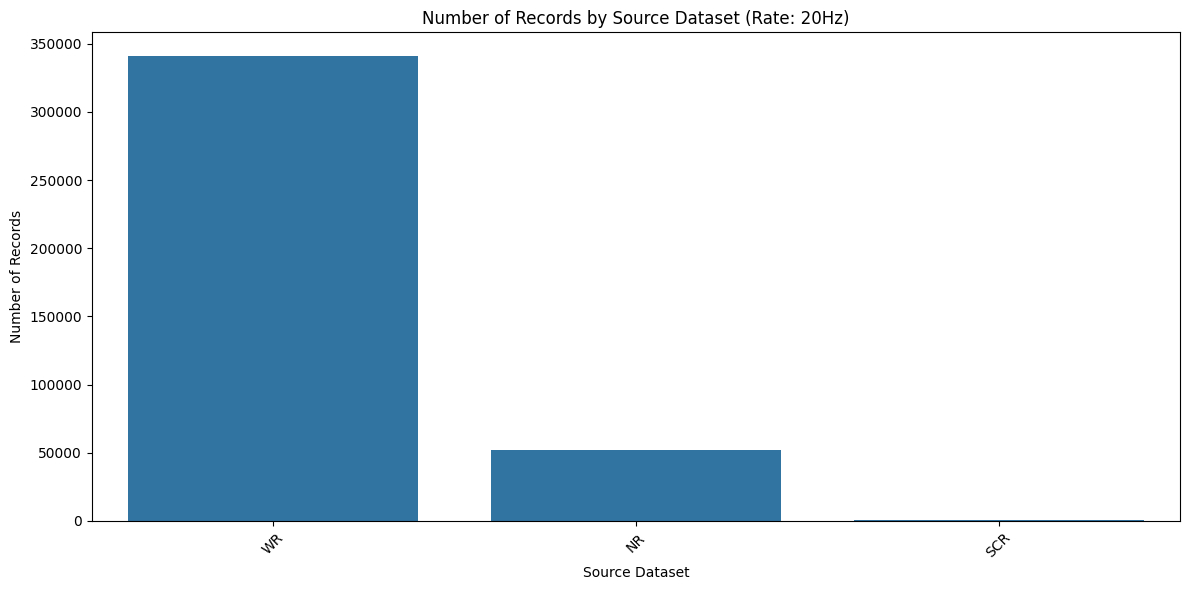

Merged dataset with rate 100Hz has the source_dataset column
Distribution of records by source dataset:


source_dataset
ECR     363007
SR      230590
SECR    135962
CR      105881
NER     104215
ECOR     93553
NFR      93138
NCR      49244
WCR      17876
Name: count, dtype: int64

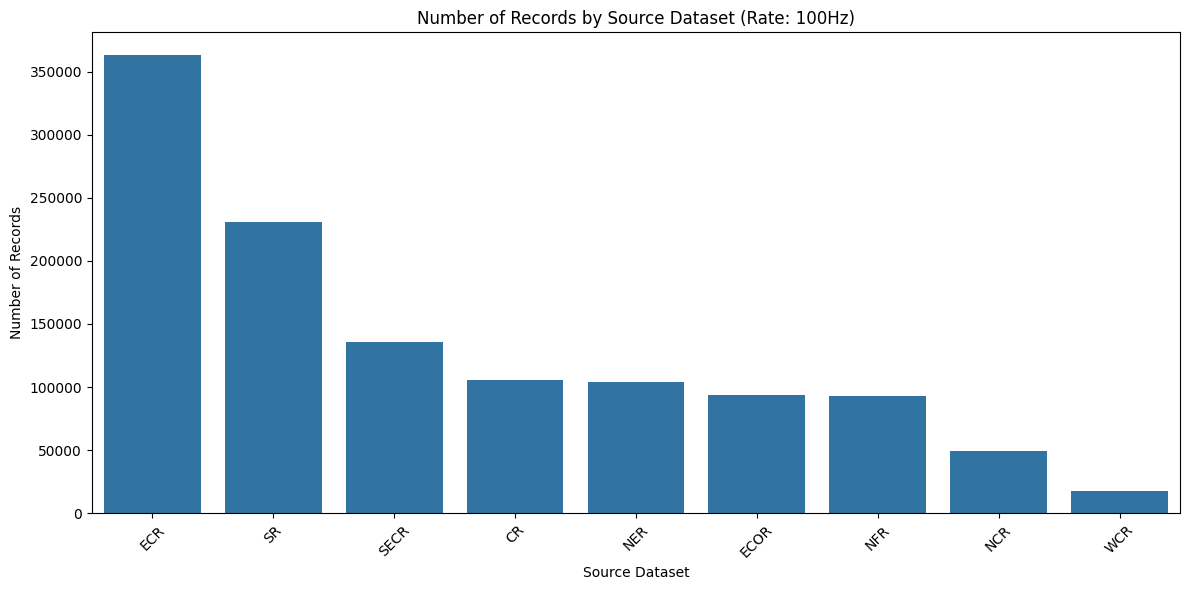

In [9]:
# Verify the source_dataset column exists in each merged dataset
for rate, df in merged_datasets.items():
    if df is not None:
        if 'source_dataset' in df.columns:
            print(f"Merged dataset with rate {rate}Hz has the source_dataset column")
            
            # Show distribution of records by source
            source_distribution = df['source_dataset'].value_counts()
            print(f"Distribution of records by source dataset:")
            display(source_distribution)
            
            # Visualize the distribution
            plt.figure(figsize=(12, 6))
            sns.barplot(x=source_distribution.index, y=source_distribution.values)
            plt.title(f'Number of Records by Source Dataset (Rate: {rate}Hz)')
            plt.xlabel('Source Dataset')
            plt.ylabel('Number of Records')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            print(f"Error: Merged dataset with rate {rate}Hz is missing the source_dataset column")

## 7. Validate Merged Data

Let's validate that the merged datasets maintain the integrity of the original data.

In [10]:
# Validate that all rows from original datasets are present in merged datasets
for rate, dataset_names in datasets_by_rate.items():
    if rate not in merged_datasets or merged_datasets[rate] is None:
        continue
        
    merged_df = merged_datasets[rate]
    original_total_rows = sum(dataframes[name].shape[0] for name in dataset_names)
    merged_total_rows = merged_df.shape[0]
    
    print(f"Validation for rate {rate}Hz:")
    print(f"  - Total rows in original datasets: {original_total_rows}")
    print(f"  - Total rows in merged dataset: {merged_total_rows}")
    
    if original_total_rows == merged_total_rows:
        print("  ✓ Row count matches perfectly")
    else:
        print(f"  ✗ Row count mismatch: difference of {merged_total_rows - original_total_rows}")
    
    # Check for any columns that may have been lost during merging
    all_original_columns = set()
    for name in dataset_names:
        all_original_columns.update(set(dataframes[name].columns))
    
    merged_columns = set(merged_df.columns) - {'source_dataset'}  # Exclude added column
    
    missing_columns = all_original_columns - merged_columns
    if missing_columns:
        print(f"  ✗ Missing columns in merged dataset: {', '.join(missing_columns)}")
    else:
        print("  ✓ All original columns maintained in merged dataset")

Validation for rate 20Hz:
  - Total rows in original datasets: 394370
  - Total rows in merged dataset: 394370
  ✓ Row count matches perfectly
  ✓ All original columns maintained in merged dataset
Validation for rate 100Hz:
  - Total rows in original datasets: 1193466
  - Total rows in merged dataset: 1193466
  ✓ Row count matches perfectly
  ✓ All original columns maintained in merged dataset


## 8. Export Final Dataset

Now we'll export the merged datasets as CSV files.

In [11]:
# Define output directory
output_dir = '/home/understressengineer/programming/SRM_PS1/processed_data'

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Export merged datasets
for rate, df in merged_datasets.items():
    if df is not None:
        output_file = os.path.join(output_dir, f'merged_data_{rate}Hz.csv')
        df.to_csv(output_file, index=False)
        print(f"Exported {df.shape[0]} rows to {output_file}")

Exported 394370 rows to /home/understressengineer/programming/SRM_PS1/processed_data/merged_data_20Hz.csv
Exported 1193466 rows to /home/understressengineer/programming/SRM_PS1/processed_data/merged_data_100Hz.csv


## 9. Summary and Conclusions

This notebook has successfully:

1. Loaded 12 CSV files from the FEB 2025 Prototype data folder
2. Examined their structures and identified polling rates
3. Grouped datasets by polling rates
4. Merged datasets with the same polling rates while preserving source information
5. Validated the merged data to ensure data integrity
6. Exported the final merged datasets to CSV files

These processed datasets can now be used for further analysis and modeling.